In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer

In [2]:
train = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/train.csv")
test = pd.read_csv("/kaggle/input/comment-category-prediction-challenge/test.csv")

In [3]:
print(train.info())
train.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 198000 entries, 0 to 197999
Data columns (total 15 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  198000 non-null  object
 1   post_id       198000 non-null  int64 
 2   emoticon_1    198000 non-null  int64 
 3   emoticon_2    198000 non-null  int64 
 4   emoticon_3    198000 non-null  int64 
 5   upvote        198000 non-null  int64 
 6   downvote      198000 non-null  int64 
 7   if_1          198000 non-null  int64 
 8   if_2          198000 non-null  int64 
 9   race          52577 non-null   object
 10  religion      52577 non-null   object
 11  gender        52577 non-null   object
 12  disability    198000 non-null  bool  
 13  comment       197999 non-null  object
 14  label         198000 non-null  int64 
dtypes: bool(1), int64(9), object(5)
memory usage: 21.3+ MB
None


,created_date,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,label
0,2024-01-18 08:43:57.397508+00:00,73,0,0,0,0,1,0,10,NaN,NaN,NaN,False,She might be a bright spot for a party keou on...,2
1,2024-03-24 21:43:11.490017+00:00,39,0,0,0,6,0,0,4,NaN,NaN,NaN,False,"Under Alaska law, a non-tribal member is not b...",0
2,2024-04-24 20:32:17.014931+00:00,31,0,1,1,0,0,0,10,NaN,NaN,NaN,False,in the future please spare me your strawman dr...,2
3,2023-05-28 22:00:14.214527+00:00,39,0,0,0,5,0,0,10,NaN,NaN,NaN,False,"PS: That should have been ""rot"" instead of ""co...",2
4,2023-09-09 23:12:05.689498+00:00,39,0,0,0,0,0,0,10,NaN,NaN,NaN,False,"Today, the confederate flag...tomorrow, the na...",2


In [4]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 102000 entries, 0 to 101999
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   created_date  102000 non-null  object
 1   post_id       102000 non-null  int64 
 2   emoticon_1    102000 non-null  int64 
 3   emoticon_2    102000 non-null  int64 
 4   emoticon_3    102000 non-null  int64 
 5   upvote        102000 non-null  int64 
 6   downvote      102000 non-null  int64 
 7   if_1          102000 non-null  int64 
 8   if_2          102000 non-null  int64 
 9   race          26731 non-null   object
 10  religion      26731 non-null   object
 11  gender        26731 non-null   object
 12  disability    102000 non-null  bool  
 13  comment       102000 non-null  object
dtypes: bool(1), int64(8), object(5)
memory usage: 10.2+ MB


,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,disability,label
post_id,1.000000,0.034567,0.012501,0.049622,-0.019455,0.065511,-0.000977,0.010235,-0.010910,0.022063
emoticon_1,0.034567,1.000000,0.092087,0.144864,0.128124,0.177236,-0.002624,-0.004116,-0.005887,-0.003218
emoticon_2,0.012501,0.092087,1.000000,0.140236,0.081580,0.169366,0.001741,0.003919,0.000235,0.021597
emoticon_3,0.049622,0.144864,0.140236,1.000000,0.170662,0.371039,-0.000514,0.007191,-0.001087,0.027273
upvote,-0.019455,0.128124,0.081580,0.170662,1.000000,0.314557,-0.001654,-0.000674,0.002080,0.040181
downvote,0.065511,0.177236,0.169366,0.371039,0.314557,1.000000,0.000354,0.006307,-0.003465,0.044908
if_1,-0.000977,-0.002624,0.001741,-0.000514,-0.001654,0.000354,1.000000,0.008174,0.129887,0.007543
if_2,0.010235,-0.004116,0.003919,0.007191,-0.000674,0.006307,0.008174,1.000000,0.023374,0.232902
disability,-0.010910,-0.005887,0.000235,-0.001087,0.002080,-0.003465,0.129887,0.023374,1.000000,0.053809
label,0.022063,-0.003218,0.021597,0.027273,0.040181,0.044908,0.007543,0.232902,0.053809,1.000000


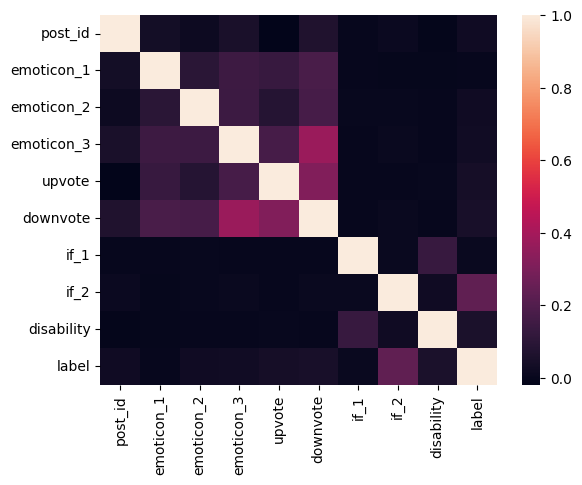

In [5]:
corr = train.select_dtypes(exclude='object').corr()
sns.heatmap(corr)
corr

In [6]:
import re
import string

def normalize_text(text):

    # Handle NaN / non-string values
    if not isinstance(text, str):
        return ""

    # 1. Remove numbers
    text = re.sub(r'\d+', '', text)

    # 2. Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)

    # 3. Lowercase
    text = text.lower()

    # 4. Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # 5. Remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()

    return text


In [7]:
train['emoticon_3'].value_counts()

emoticon_3
0     180835
1      13017
2       2777
3        764
4        309
5        132
6         79
7         41
8         14
10        12
9          9
11         4
14         2
13         2
12         2
17         1
Name: count, dtype: int64

In [8]:
for df in [train, test]:

    # Identity indicators
    df["race"] = df["race"].notna().astype(int)
    df["religion"] = df["religion"].notna().astype(int)
    df["gender"] = df["gender"].notna().astype(int)
    df["disability"] = df["disability"].astype(int)

    # Date features
    df["created_date"] = pd.to_datetime(df["created_date"], errors="coerce")
    df["hour"] = df["created_date"].dt.hour
    df["dayofweek"] = df["created_date"].dt.dayofweek
    df["is_weekend"] = df["dayofweek"].isin([5, 6]).astype(int)
    df.drop(columns=["created_date"], inplace=True)

    # Vote features
    df["total_vote"] = df["upvote"] + df["downvote"]
    df["log_upvote"] = np.log1p(df["upvote"])
    df["log_downvote"] = np.log1p(df["downvote"])
    df["log_total_vote"] = np.log1p(df["total_vote"])
    df['comment'] = df['comment'].apply(normalize_text)

# Safe row drop
train.dropna(subset=["comment", "label"], inplace=True)

In [9]:
X = train.drop(columns=['label'])
y = train['label']

In [10]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,stratify=y,random_state=42, test_size=0.2)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((158400, 20), (39600, 20), (158400,), (39600,))

In [11]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import MaxAbsScaler,StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

numeric_cols = [col for col in X.select_dtypes(exclude='object').columns
                if col not in ['emoticon_1', 'emoticon_2', 'emoticon_3']]

ct = ColumnTransformer(
    transformers=[
        ('scaler', StandardScaler(with_mean=False), numeric_cols),
        ('min_abs',MaxAbsScaler(), ['emoticon_1', 'emoticon_2', 'emoticon_3']),
        ('vectorizer', TfidfVectorizer(
            ngram_range=(1,2),
            max_features=20_000,
            min_df=5,
            max_df=0.9,
            stop_words='english'
        ), 'comment')
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)

X_train_tf = ct.fit_transform(X_train)


In [12]:
X_test_tf = ct.transform(X_test)

In [13]:
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.linear_model import SGDClassifier
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import r2_score, accuracy_score, classification_report

In [14]:
# from xgboost import XGBClassifier
# from sklearn.metrics import accuracy_score

# # model
# model = XGBClassifier(
#     n_estimators=200,
#     learning_rate=0.1,
#     max_depth=6,
#     subsample=0.8,
#     colsample_bytree=0.8,
#     objective='multi:softprob',   # use 'binary:logistic' for binary classification
#     eval_metric='mlogloss',
#     n_jobs=-1,
#     random_state=42
# )

# # train
# model.fit(X_train_tf, y_train)

# # prediction + score
# y_pred = model.predict(X_test_tf)
# r2_score(y_test, y_pred)


In [15]:
# model = LogisticRegression(C=0.5,max_iter=1000, n_jobs=-1)
# model.fit(X_train_tf, y_train)
# accuracy_score(y_test, model.predict(X_test_tf))

In [16]:
# from lightgbm import LGBMClassifier
# from sklearn.metrics import accuracy_score

# # Initialize model
# model = LGBMClassifier(
#     n_estimators=100,
#     learning_rate=0.1,
#     max_depth=-1,
#     random_state=42,
#     n_jobs=-1
# )

# # Train
# model.fit(X_train_tf, y_train)

# # Predict
# y_pred = model.predict(X_test_tf)

# # Accuracy
# accuracy_score(y_test, y_pred)


In [17]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score

# Initialize model
model = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.1,
    max_depth=-1,
    random_state=42,
    n_jobs=-1
)

# Train
model.fit(X_train_tf, y_train)

# Predict
y_pred = model.predict(X_test_tf)

# Accuracy
accuracy_score(y_test, y_pred)


[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 19.355954 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 855455
[LightGBM] [Info] Number of data points in the train set: 158400, number of used features: 19910
[LightGBM] [Info] Start training from score -0.550557
[LightGBM] [Info] Start training from score -2.520769
[LightGBM] [Info] Start training from score -1.154061
[LightGBM] [Info] Start training from score -3.589217


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


0.9125252525252525

In [18]:
# from lightgbm import LGBMClassifier
# from sklearn.model_selection import GridSearchCV
# from sklearn.metrics import accuracy_score
# import numpy as np

# lgbm = LGBMClassifier(
#     random_state=42,
#     learning_rate=0.1,
#     n_jobs=-1,
#     force_col_wise=True
# )

# param_dist = {
#     'n_estimators': [300, 500, 700]
# }

# random_search = GridSearchCV(
#     estimator=lgbm,
#     param_grid=param_dist,
#     scoring='accuracy',
#     cv=3,
#     verbose=2
# )

# random_search.fit(X_train_tf, y_train)

# best_model = random_search.best_estimator_

# print("Best Params:", random_search.best_params_)
# print("Accuracy:", accuracy_score(y_test, best_model.predict(X_test_tf)))


In [19]:
# from sklearn.svm import LinearSVC
# from sklearn.model_selection import GridSearchCV

# param_grid = {
#     'C': [0.1, 0.5, 1, 2, 5]
# }

# grid = GridSearchCV(
#     LinearSVC(),
#     param_grid,
#     cv=3,
#     scoring='accuracy',
#     n_jobs=-1,
#     verbose=2
# )

# grid.fit(X_train_tf, y_train)

# print("Best C:", grid.best_params_)
# print("Accuracy:", grid.score(X_test_tf, y_test))


In [20]:
# from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score

# for C in [0.01, 0.1, 0.5, 1.0, 2.0, 5.0]:
#     model = LogisticRegression(
#         C=C,
#         max_iter=2000,
#         n_jobs=-1
#     )
    
#     model.fit(X_train_tf, y_train)
#     acc = accuracy_score(y_test, model.predict(X_test_tf))
    
#     print(f"C={C} -> {acc}")


In [21]:
# from sklearn.neural_network import MLPClassifier
# from sklearn.metrics import accuracy_score

# mlp_class = MLPClassifier(
#     hidden_layer_sizes=(100,),
#     activation="relu",
#     solver="adam",
#     max_iter=500,
#     early_stopping=True,
#     n_iter_no_change=5,
#     random_state=42
# )


# mlp_class.fit(X_train_tf, y_train)

# accuracy_score(y_test, mlp_class.predict(X_test_tf))

In [22]:
# configs = [
#     (100,),
#     (128,64),
#     (256,128,64)
# ]

# for config in configs:
#     model = MLPClassifier(
#         hidden_layer_sizes=config,
#         max_iter=500,
#         early_stopping=True,
#         random_state=42
#     )
    
#     model.fit(X_train_tf, y_train)
#     acc = accuracy_score(y_test, model.predict(X_test_tf))
    
#     print(config, "->", acc)


In [23]:
# from sklearn.model_selection import GridSearchCV

# log_reg = LogisticRegression(
#     solver='saga',
#     max_iter=1000,
#     n_jobs=-1
# )
# param_grid = {
#     'C': [0.1, 1.0, 5.0],
#     'penalty': ['l2'],
#     'class_weight': [None, 'balanced']
# }
# grid = GridSearchCV(
#     estimator=log_reg,
#     param_grid=param_grid,
#     scoring='f1_macro',   # change if Kaggle uses accuracy
#     cv=3,
#     verbose=2,
#     n_jobs=-1
# )

# grid.fit(X_train_tf, y_train)


In [24]:
# r2_score(y_test, grid.best_estimator_.predict(X_test_tf))

In [25]:
# from sklearn.linear_model import Perceptron

# perc = Perceptron(random_state=1729,eta0=1,fit_intercept=True,warm_start=True,validation_fraction=0.1,early_stopping=True)
# perc.fit(X_train_tf,y_train)
# r2_score(y_test, perc.predict(X_test_tf))

In [26]:
# from sklearn.model_selection import GridSearchCV
# param_grid={
#     'alpha':[0.0001, 0.0005, 0.001, 0.005],
#     'eta0' : [0.01, 0.05, 0.1, 0.5]
# }
# gscv_sgd = GridSearchCV(SGDClassifier(loss='log_loss',learning_rate='constant',random_state=1729),param_grid,cv=5,scoring='accuracy')
# gscv_sgd.fit(X_train_tf,y_train)
# r2_score(y_test,gscv_sgd.best_estimator_.predict(X_test_tf))

In [27]:
# from sklearn.svm import SVC
# svm = SVC(kernel='rbf',decision_function_shape='ovr',random_state=1729,C=1)
# svm.fit(X_train_tf,y_train)
# r2_score(y_test,svm.predict(X_test_tf))

In [28]:
# from sklearn.tree import DecisionTreeClassifier
# dtc = DecisionTreeClassifier(criterion='entropy',splitter='random',min_samples_split=4,min_impurity_decrease=0.0001,random_state=42)
# dtc.fit(X_train_tf,y_train)
# r2_score(y_test,dtc.predict(X_test_tf))

In [29]:
# lin_svc = LinearSVC()
# lin_svc.fit(X_train_tf, y_train)
# r2_score(y_test, lin_svc.predict(X_test_tf))

In [30]:
# sgd_clf = SGDClassifier(
#     loss="log_loss",      # logistic regression
#     penalty="l2",
#     alpha=1e-4,
#     max_iter=1000,
#     tol=1e-3,
#     random_state=42,
#     n_jobs=-1
# )
# sgd_clf.fit(X_train_tf, y_train)
# r2_score(y_test, sgd_clf.predict(X_test_tf))

In [31]:
test.head()

,post_id,emoticon_1,emoticon_2,emoticon_3,upvote,downvote,if_1,if_2,race,religion,gender,disability,comment,hour,dayofweek,is_weekend,total_vote,log_upvote,log_downvote,log_total_vote
0,72,2,0,0,4,1,0,10,0,0,0,0,canada is being run by someone with the mental...,13,3,0,5,1.609438,0.693147,1.791759
1,123,0,0,0,0,0,0,10,0,0,0,0,and your comment is leftwing drivel,23,4,0,0,0.000000,0.000000,0.000000
2,120,0,0,0,3,0,0,4,0,0,0,0,,21,4,0,3,1.386294,0.000000,1.386294
3,123,0,0,0,0,0,0,4,0,0,0,0,trump jl blames the secret service james comey...,3,5,1,0,0.000000,0.000000,0.000000
4,123,0,0,0,0,0,0,11,0,0,0,0,it was hard enough to get the stench out of th...,2,2,0,0,0.000000,0.000000,0.000000


In [32]:
test = ct.transform(test)

In [33]:
test_label = model.predict(test)

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [34]:
import pandas as pd

submission = pd.DataFrame({
    "ID": range(1,len(test_label)+1),
    "label": test_label
})

submission.to_csv("submission.csv", index=False)


In [35]:
submission.tail()

,ID,label
101995,101996,0
101996,101997,0
101997,101998,0
101998,101999,0
101999,102000,2


# Milestones

## Milestone 1

1. What is the shape of the training dataset?

In [36]:
# train.shape

2. How many columns are present in the test dataset?

In [37]:
# test.shape[1]

3. How many columns in the training dataset have object data type?

In [38]:
# len(train.select_dtypes(include='object').columns.tolist())

4. How many numerical columns are present in the training dataset?

In [39]:
# len(train.select_dtypes(include='number').columns.tolist())

5. Which of the following columns is of boolean type?
- gender
- race
- disability
- emoticon_1

In [40]:
# train.select_dtypes(include='boolean').columns.tolist()

6. Which of the following columns have missing values?
- race
- religion
- gender
- comment

In [41]:
# train.isnull().sum()

7. How many distinct target classes are present in the dataset?

In [42]:
# train['label'].unique()

8. What percentage of the dataset approximately belongs to label 0?
- ~30%
- ~45%
- ~58%
- ~75%

In [43]:
# round((train['label'].value_counts()[0]/len(train['label']))*100,0)

9. What is the median number of upvotes per comment?

In [44]:
# train['upvote'].median()

10. Which numerical feature shows the largest maximum value?
- upvote
- downvote
- if_1
- if_2

In [45]:
# cols = ['upvote','downvote','if_1','if_2']
# for i in cols:
#     print(i,train[i].max())

11. What is the minimum value of if_2?

In [46]:
# train['if_2'].min()

## Milestone 2